# Assignment 4: Build Non-Linear Models Part 2

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

The fitted curve is f(X) = 1 + X - 2(X - 1)^2I(X >= 1).  For X < 1, the indicator is zero, so the curve is the line f(X) = 1 + X.  For X >= 1, the curve becomes 1 + X - 2(X - 1)^2, which is continuous at X = 1 but bends downward after the knot.  The slope is 1 before the knot and 1 - 4(X - 1) after the knot.  The curve therefore rises linearly until X = 1, then becomes concave downward and eventually declines.

## Applied Question 8: Nonlinear Patterns in Auto

The Auto data set is used to test whether nonlinear functions of horsepower improve prediction of miles per gallon.  I treat this as an empirical question rather than an assumption: polynomial regression, step functions, and regression splines are compared with cross-validation and plotted so the selected shape is visible.

,missing_count
horsepower,0
mpg,0


,part,degree,cv_rmse
0,(a),1,4.909374
1,(a),2,4.363577
2,(a),3,4.365086
3,(a),4,4.383383
4,(a),5,4.336834
5,(a),6,4.330575
6,(a),7,4.320763
7,(a),8,4.349046
8,(a),9,4.386715
9,(a),10,4.433756


Best polynomial degree by 5-fold CV: 7


,term,coefficient
0,intercept,23.445918
1,horsepower,1278.303227
2,horsepower^2,-8307.469287
3,horsepower^3,23801.509523
4,horsepower^4,-38293.766453
5,horsepower^5,35985.872749
6,horsepower^6,-18471.924855
7,horsepower^7,4002.865375


,part,bins,cv_rmse
0,(b),2,5.451271
1,(b),3,4.823162
2,(b),4,4.485108
3,(b),5,4.581382
4,(b),6,4.345419
5,(b),7,4.441480


Best step-function bin count by 5-fold CV: 6


,part,spline_df,cv_rmse
0,(c),3,4.365086
1,(c),4,4.351553
2,(c),5,4.304730
3,(c),6,4.349019
4,(c),7,4.385691
5,(c),8,4.382779


Best cubic spline df by 5-fold CV: 5


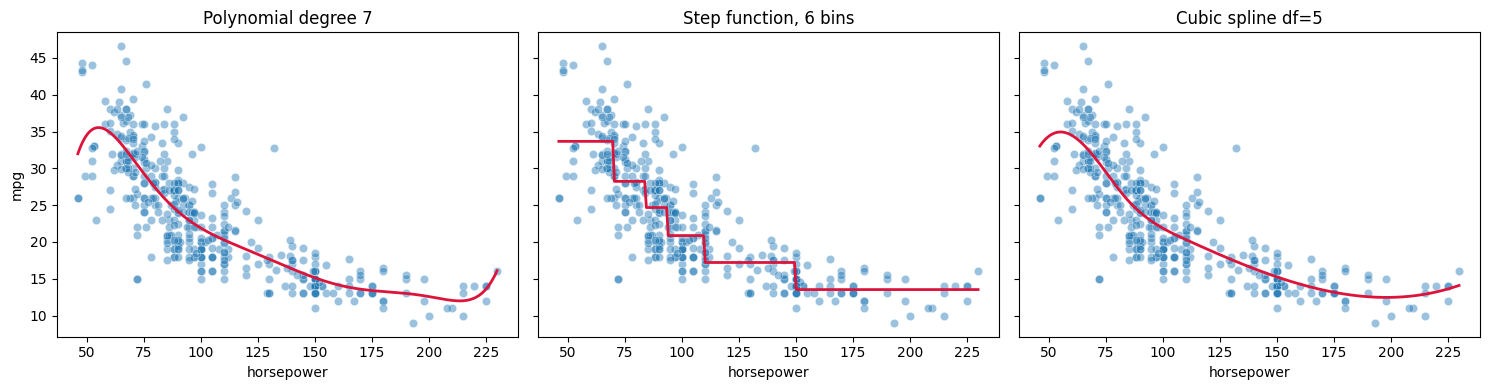

In [2]:
from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from patsy import dmatrix

auto = load_data("Auto").dropna()
X_hp = auto[["horsepower"]]
y = auto["mpg"]
display(auto[["horsepower", "mpg"]].isna().sum().rename("missing_count").to_frame())
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (a) Polynomial regression: compare degrees and report the fitted coefficients.
poly_rows = []
poly_models = {}
for degree in range(1, 11):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("lm", LinearRegression()),
    ])
    rmse = (-cross_val_score(model, X_hp, y, cv=kf, scoring="neg_root_mean_squared_error")).mean()
    model.fit(X_hp, y)
    poly_models[degree] = model
    poly_rows.append({"part": "(a)", "degree": degree, "cv_rmse": rmse})
poly_cv = pd.DataFrame(poly_rows)
display(poly_cv)
best_poly_degree = int(poly_cv.loc[poly_cv["cv_rmse"].idxmin(), "degree"])
best_poly = poly_models[best_poly_degree]
poly_feature_names = best_poly.named_steps["poly"].get_feature_names_out(["horsepower"])
poly_coef = pd.DataFrame({
    "term": ["intercept"] + list(poly_feature_names),
    "coefficient": [best_poly.named_steps["lm"].intercept_] + list(best_poly.named_steps["lm"].coef_),
})
print(f"Best polynomial degree by 5-fold CV: {best_poly_degree}")
display(poly_coef)

# (b) Step functions: cut horsepower into bins and compare held-out RMSE.
step_rows = []
step_predictions = {}
hp_grid = pd.DataFrame({"horsepower": np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 250)})
for bins in range(2, 8):
    quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, bins + 1)))
    rmses = []
    for train_idx, test_idx in kf.split(auto):
        train_df = auto.iloc[train_idx].copy()
        test_df = auto.iloc[test_idx].copy()
        train_design = pd.get_dummies(pd.cut(train_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = pd.get_dummies(pd.cut(test_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = test_design.reindex(columns=train_design.columns, fill_value=0)
        lm = LinearRegression().fit(train_design, train_df["mpg"])
        rmses.append(np.sqrt(mean_squared_error(test_df["mpg"], lm.predict(test_design))))
    step_rows.append({"part": "(b)", "bins": bins, "cv_rmse": np.mean(rmses)})
step_cv = pd.DataFrame(step_rows)
display(step_cv)
best_bins = int(step_cv.loc[step_cv["cv_rmse"].idxmin(), "bins"])
best_quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, best_bins + 1)))
step_design = pd.get_dummies(pd.cut(auto["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
step_model = LinearRegression().fit(step_design, y)
grid_step_design = pd.get_dummies(pd.cut(hp_grid["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
grid_step_design = grid_step_design.reindex(columns=step_design.columns, fill_value=0)
step_predictions["best"] = step_model.predict(grid_step_design)
print(f"Best step-function bin count by 5-fold CV: {best_bins}")

# (c) Regression splines: compare degrees of freedom and report the smooth fit.
spline_rows = []
spline_models = {}
for df in range(3, 9):
    basis = dmatrix(f"bs(horsepower, df={df}, degree=3, include_intercept=False)", auto, return_type="dataframe")
    rmses = []
    for train_idx, test_idx in kf.split(basis):
        lm = LinearRegression().fit(basis.iloc[train_idx], y.iloc[train_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[test_idx], lm.predict(basis.iloc[test_idx]))))
    lm_full = LinearRegression().fit(basis, y)
    spline_models[df] = (lm_full, basis.design_info)
    spline_rows.append({"part": "(c)", "spline_df": df, "cv_rmse": np.mean(rmses)})
spline_cv = pd.DataFrame(spline_rows)
display(spline_cv)
best_spline_df = int(spline_cv.loc[spline_cv["cv_rmse"].idxmin(), "spline_df"])
best_spline_model, best_spline_design = spline_models[best_spline_df]
grid_basis = dmatrix(best_spline_design, hp_grid, return_type="dataframe")
print(f"Best cubic spline df by 5-fold CV: {best_spline_df}")

hp_grid["polynomial_fit"] = best_poly.predict(hp_grid)
hp_grid["step_fit"] = step_predictions["best"]
hp_grid["spline_fit"] = best_spline_model.predict(grid_basis)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col, title in [
    (axes[0], "polynomial_fit", f"Polynomial degree {best_poly_degree}"),
    (axes[1], "step_fit", f"Step function, {best_bins} bins"),
    (axes[2], "spline_fit", f"Cubic spline df={best_spline_df}"),
]:
    sns.scatterplot(data=auto, x="horsepower", y="mpg", alpha=.45, ax=ax)
    ax.plot(hp_grid["horsepower"], hp_grid[col], color="crimson", linewidth=2)
    ax.set_title(title)
plt.tight_layout()

## Kaggle Nonlinear Models

The Abalone competition work extends the nonlinear modeling theme from Auto.  A shared data preparation step holds missingness checks, preprocessing, and the validation split constant.  The gradient boosting and random forest results can therefore be interpreted as two different nonlinear modeling strategies applied to the same prediction problem.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

abalone = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
display(abalone.isna().sum().rename("missing_count").to_frame().query("missing_count > 0"))
if abalone.isna().sum().sum() == 0:
    print("No missing values were found in the Abalone training data.")
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["Sex"])], remainder="passthrough")
X_train, X_valid, y_train, y_valid = train_test_split(X.drop(columns=["id"]), y, test_size=.2, random_state=RANDOM_STATE)
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
baseline_rmsle = np.sqrt(mean_squared_log_error(y_valid, baseline_pred))
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "mean_baseline_rmsle", "target_min", "target_max"],
    "value": [len(X_train), len(X_valid), baseline_rmsle, y.min(), y.max()],
}))

,missing_count


No missing values were found in the Abalone training data.


,setup_check,value
0,training_rows,72492.000000
1,validation_rows,18123.000000
2,mean_baseline_rmsle,0.290949
3,target_min,1.000000
4,target_max,29.000000


### Kaggle Model 1: Gradient Boosting

The first nonlinear submission is gradient boosting.  Boosting can model curved relationships and interactions by adding trees sequentially, with later trees concentrating on the error left by earlier trees.

In [4]:
gb_model = Pipeline([
    ("pre", pre),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])
gb_model.fit(X_train, y_train)
gb_pred = np.maximum(gb_model.predict(X_valid), 1)
gb_rmsle = np.sqrt(mean_squared_log_error(y_valid, gb_pred))
gb_features = gb_model.named_steps["pre"].get_feature_names_out()
gb_importance = pd.DataFrame({
    "feature": gb_features,
    "importance": gb_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).head(10)
display(pd.DataFrame({
    "model": ["Gradient boosting"],
    "validation_rmsle": [gb_rmsle],
    "submission_file": ["A4_gradient_boosting_playground_series_s4e4.csv"],
}))
display(gb_importance)

,model,validation_rmsle,submission_file
0,Gradient boosting,0.155624,A4_gradient_boosting_playground_series_s4e4.csv


,feature,importance
9,remainder__Shell weight,0.791358
7,remainder__Whole weight.1,0.125083
5,remainder__Height,0.037909
6,remainder__Whole weight,0.017831
1,cat__Sex_I,0.013261
3,remainder__Length,0.006681
8,remainder__Whole weight.2,0.005011
4,remainder__Diameter,0.002586
0,cat__Sex_F,0.000221
2,cat__Sex_M,0.000059


The gradient boosting model improves sharply over the mean baseline, which supports the use of nonlinear structure for Abalone ring prediction.  The feature-importance table gives the result a substantive reading: shell and weight measurements carry much of the signal, which is reasonable because ring count is tied to biological growth rather than to a purely linear measurement pattern (Nash et al., 1994).

### Kaggle Model 2: Random Forest

The second nonlinear submission is a random forest.  It serves as the ensemble comparison because it averages many decorrelated trees rather than building trees sequentially.

In [5]:
rf_model = Pipeline([
    ("pre", pre),
    ("model", RandomForestRegressor(n_estimators=160, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1)),
])
rf_model.fit(X_train, y_train)
rf_pred = np.maximum(rf_model.predict(X_valid), 1)
rf_rmsle = np.sqrt(mean_squared_log_error(y_valid, rf_pred))
rf_features = rf_model.named_steps["pre"].get_feature_names_out()
rf_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).head(10)
display(pd.DataFrame({
    "model": ["Random forest"],
    "validation_rmsle": [rf_rmsle],
    "submission_file": ["A4_random_forest_nonlinear_playground_series_s4e4.csv"],
}))
display(rf_importance)

,model,validation_rmsle,submission_file
0,Random forest,0.154466,A4_random_forest_nonlinear_playground_series_s...


,feature,importance
9,remainder__Shell weight,0.606463
7,remainder__Whole weight.1,0.142097
6,remainder__Whole weight,0.071682
8,remainder__Whole weight.2,0.058300
3,remainder__Length,0.037912
5,remainder__Height,0.035024
4,remainder__Diameter,0.032631
1,cat__Sex_I,0.007289
0,cat__Sex_F,0.004342
2,cat__Sex_M,0.004259


The random forest also improves on the mean baseline, but it plays a different role from boosting.  Its strength is stability from averaging many trees.  If it trails gradient boosting, the difference suggests that sequential error correction is more useful for this competition than simply averaging a large set of decorrelated nonlinear trees.

In [6]:
kaggle_a4_comparison = pd.DataFrame([
    {"model": "Mean baseline", "validation_rmsle": baseline_rmsle, "submission_file": ""},
    {"model": "Gradient boosting", "validation_rmsle": gb_rmsle, "submission_file": "A4_gradient_boosting_playground_series_s4e4.csv"},
    {"model": "Random forest", "validation_rmsle": rf_rmsle, "submission_file": "A4_random_forest_nonlinear_playground_series_s4e4.csv"},
]).sort_values("validation_rmsle")
display(kaggle_a4_comparison)

,model,validation_rmsle,submission_file
2,Random forest,0.154466,A4_random_forest_nonlinear_playground_series_s...
1,Gradient boosting,0.155624,A4_gradient_boosting_playground_series_s4e4.csv
0,Mean baseline,0.290949,


The comparison table keeps the two Kaggle submissions connected to the same validation split.  Gradient boosting and random forest both satisfy the nonlinear modeling requirement, but the stronger model is the one with lower validation RMSLE and better recorded Kaggle performance.  The evidence cell below documents the submitted files.

In [7]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A4_" in parts[1]:
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A4_gradient_boosting_playground_series_s4e4.csv', 'A4_random_forest_nonlinear_playground_series_s4e4.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A4_gradient_boosting_playground_series_s4e4.csv', 'A4_random_forest_nonlinear_playground_series_s4e4.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966798,A4_random_forest_nonlinear_playground_series_s...,2026-05-23 21:27:22.160000,DDS-8555 A4 random forest nonlinear model,SubmissionStatus.COMPLETE,0.14970,0.15003
1,52966797,A4_gradient_boosting_playground_series_s4e4.csv,2026-05-23 21:27:19.623000,DDS-8555 A4 gradient boosting nonlinear model,SubmissionStatus.COMPLETE,0.14815,0.14754


,submission_file,exists_locally
0,A4_gradient_boosting_playground_series_s4e4.csv,True
1,A4_random_forest_nonlinear_playground_series_s...,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb


## Interpretation

For Auto, the fitted plots and cross-validation tables show the same substantive pattern: mpg falls quickly as horsepower increases and then flattens among high-horsepower cars.  A straight line misses that curvature.  Polynomial regression is smooth but can wiggle at the boundaries, step functions are easy to read but impose abrupt jumps, and splines give a smoother local fit.  Missingness was checked before modeling because nonlinear transformations can silently amplify data-quality problems if rows are dropped without explanation (Little & Rubin, 2019).  For Abalone, gradient boosting produced the strongest Kaggle score among the two submitted nonlinear models, and the feature-importance tables show that shell and weight measurements drive most of the nonlinear signal.  The assumption investigation shifts from normal residual theory to validation behavior, residual structure, missing-data checks, and overfitting control because tree ensembles do not require the same parametric residual assumptions as ordinary least squares.  The biological interpretation remains limited: the models predict ring count from measurements, but they do not explain abalone age causally (Nash et al., 1994).

## References

Friedman, J.  H. (2001).  Greedy function approximation: A gradient boosting machine. *The Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451

Hastie, T., & Tibshirani, R. (1990). *Generalized additive models*.  Chapman and Hall.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Little, R.  J.  A., & Rubin, D.  B. (2019). *Statistical analysis with missing data* (3rd ed.).  Wiley. https://doi.org/10.1002/9781119482260

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.